# Phase 8 — Notebook 8: BERT vs. GPT — A Complete Conceptual Comparison

> **Phase Continuity**: Notebooks 4–7 gave deep dives into each model family individually. This notebook synthesizes everything into a unified comparative understanding — the architectural fork, capability trade-offs, embedding spaces, and the modern convergence.

---

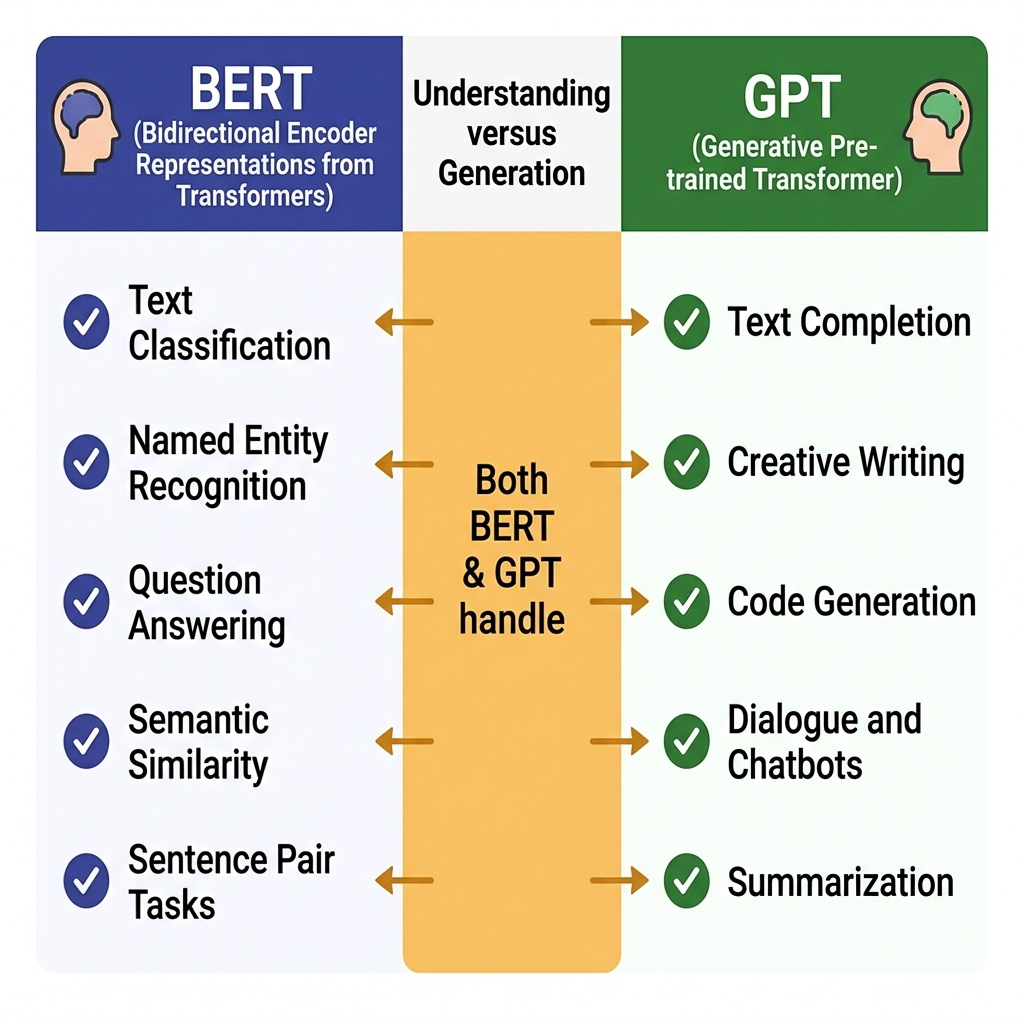

*Figure 1: BERT vs GPT Task Suitability — the architectural difference determines which tasks each model excels at*



## 1. The Architectural Fork — One Source, Two Philosophies

Both BERT and GPT descend from the same parent: Vaswani et al.'s *Attention Is All You Need* (2017). But they made opposite choices about which half of the Transformer to use:

```
            Transformer (2017)
           /                   \
    Encoder Stack          Decoder Stack
   (Bidirectional)        (Causal/Masked)
         |                       |
       BERT                     GPT
    (Google, 2018)          (OpenAI, 2018)
```

This single architectural choice — **which direction the attention flows** — determines almost everything about what each model is good at.

---

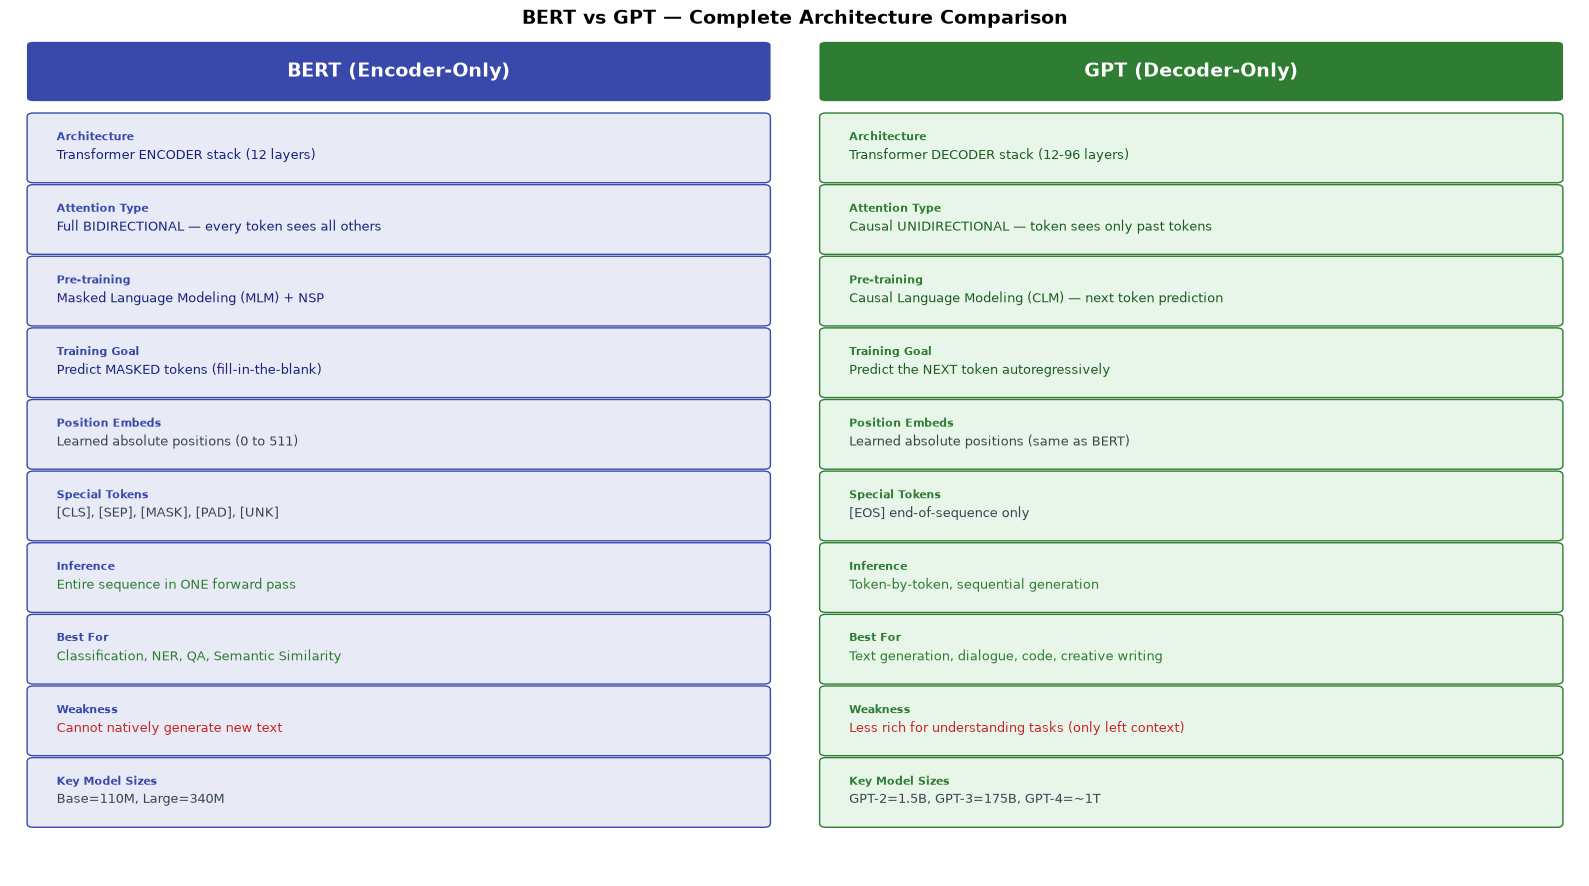

In [1]:
# Side-by-side architecture comparison visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

def draw_model_card(ax, name, color, accent, rows):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, len(rows) * 1.6 + 1.5)
    ax.axis('off')
    total_h = len(rows) * 1.6 + 1.5
    # Header
    header = mpatches.FancyBboxPatch((0.3, total_h - 1.2), 9.4, 1.1,
                                      boxstyle='round,pad=0.1',
                                      facecolor=accent, edgecolor='white', lw=2)
    ax.add_patch(header)
    ax.text(5, total_h - 0.65, name, ha='center', va='center',
            fontsize=14, fontweight='bold', color='white')
    # Rows
    for i, (label, value, val_color) in enumerate(rows):
        y = total_h - 1.4 - (i+1)*1.5
        row_bg = mpatches.FancyBboxPatch((0.3, y), 9.4, 1.3,
                                          boxstyle='round,pad=0.08',
                                          facecolor=color, edgecolor=accent, lw=1)
        ax.add_patch(row_bg)
        ax.text(0.6, y+1.0, label, fontsize=8, color=accent, fontweight='bold', va='top')
        ax.text(0.6, y+0.5, value, fontsize=9, color=val_color, va='center')

bert_rows = [
    ('Architecture',    'Transformer ENCODER stack (12 layers)', '#1A237E'),
    ('Attention Type',  'Full BIDIRECTIONAL — every token sees all others', '#1A237E'),
    ('Pre-training',    'Masked Language Modeling (MLM) + NSP', '#1A237E'),
    ('Training Goal',   'Predict MASKED tokens (fill-in-the-blank)', '#1A237E'),
    ('Position Embeds', 'Learned absolute positions (0 to 511)', '#37474F'),
    ('Special Tokens',  '[CLS], [SEP], [MASK], [PAD], [UNK]', '#37474F'),
    ('Inference',       'Entire sequence in ONE forward pass', '#2E7D32'),
    ('Best For',        'Classification, NER, QA, Semantic Similarity', '#2E7D32'),
    ('Weakness',        'Cannot natively generate new text', '#C62828'),
    ('Key Model Sizes', 'Base=110M, Large=340M', '#37474F'),
]
gpt_rows = [
    ('Architecture',    'Transformer DECODER stack (12-96 layers)', '#1B5E20'),
    ('Attention Type',  'Causal UNIDIRECTIONAL — token sees only past tokens', '#1B5E20'),
    ('Pre-training',    'Causal Language Modeling (CLM) — next token prediction', '#1B5E20'),
    ('Training Goal',   'Predict the NEXT token autoregressively', '#1B5E20'),
    ('Position Embeds', 'Learned absolute positions (same as BERT)', '#37474F'),
    ('Special Tokens',  '[EOS] end-of-sequence only', '#37474F'),
    ('Inference',       'Token-by-token, sequential generation', '#2E7D32'),
    ('Best For',        'Text generation, dialogue, code, creative writing', '#2E7D32'),
    ('Weakness',        'Less rich for understanding tasks (only left context)', '#C62828'),
    ('Key Model Sizes', 'GPT-2=1.5B, GPT-3=175B, GPT-4=~1T', '#37474F'),
]
draw_model_card(axes[0], 'BERT (Encoder-Only)', '#E8EAF6', '#3949AB', bert_rows)
draw_model_card(axes[1], 'GPT (Decoder-Only)',  '#E8F5E9', '#2E7D32', gpt_rows)

plt.suptitle('BERT vs GPT — Complete Architecture Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_bert_gpt_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. The Core Difference: Attention Pattern

The single most important architectural distinction is the **attention mask**:

- **BERT Encoder**: Full attention matrix — every token attends to every other token. During pre-training, the model fills in masked tokens using **both left AND right context**.

- **GPT Decoder**: Triangular (causal) attention mask — token at position `i` can only attend to positions `0, 1, ..., i`. During pre-training and inference, the model always predicts the **next token** using only past tokens.

---

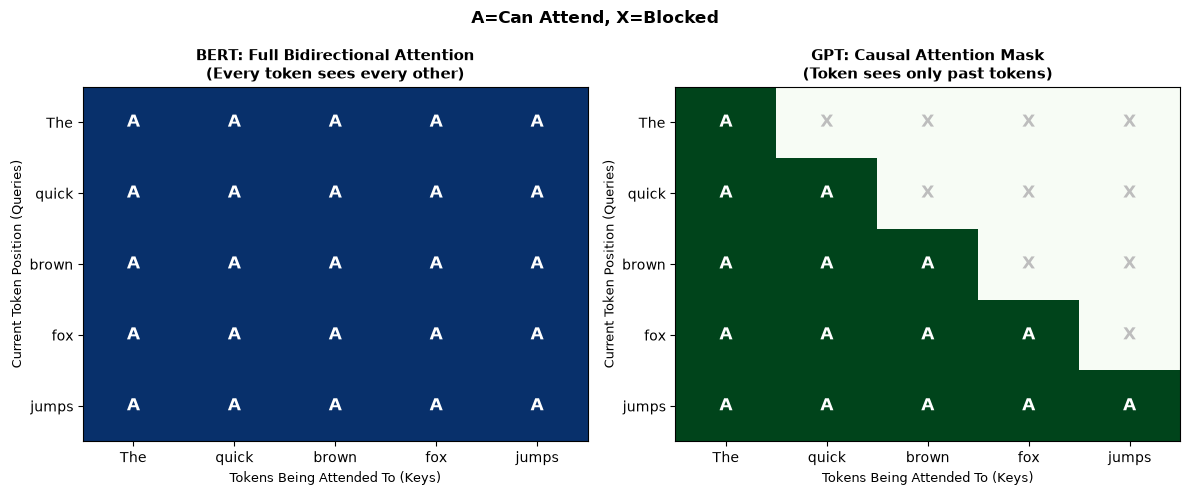

BERT: 25/25 attention connections allowed (100%)
GPT:  15/25 attention connections allowed (60%) — upper triangle blocked


In [2]:
import numpy as np
import matplotlib.pyplot as plt

tokens = ['The', 'quick', 'brown', 'fox', 'jumps']
n = len(tokens)
bert_mask = np.ones((n, n))        # Full attention
gpt_mask  = np.tril(np.ones((n, n)))  # Causal mask

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mask, title, cmap in [
    (axes[0], bert_mask, 'BERT: Full Bidirectional Attention\n(Every token sees every other)', 'Blues'),
    (axes[1], gpt_mask,  'GPT: Causal Attention Mask\n(Token sees only past tokens)',         'Greens'),
]:
    im = ax.imshow(mask, cmap=cmap, aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(tokens, fontsize=10)
    ax.set_yticklabels(tokens, fontsize=10)
    ax.set_xlabel('Tokens Being Attended To (Keys)', fontsize=9)
    ax.set_ylabel('Current Token Position (Queries)', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    for i in range(n):
        for j in range(n):
            val = 'A' if mask[i,j] == 1 else 'X'
            col = 'white' if mask[i,j] == 1 else '#BDBDBD'
            ax.text(j, i, val, ha='center', va='center', fontsize=12,
                    fontweight='bold', color=col)

plt.suptitle('A=Can Attend, X=Blocked', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_attention_masks_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('BERT: 25/25 attention connections allowed (100%)')
print('GPT:  15/25 attention connections allowed (60%) — upper triangle blocked')

## 3. Embedding Space Comparison

One of the most practical differences: the embeddings each model produces have different qualities suited to different tasks.

BERT's `[CLS]` embeddings are optimized for **discrimination** — sentences with different meanings are pushed apart in embedding space. This makes them excellent for semantic similarity, clustering, and classification.

GPT's hidden states are optimized for **prediction** — the representation at each position is shaped to predict the next token. This creates embeddings rich in sequential and generative patterns, but less discriminative for classification tasks.

---

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

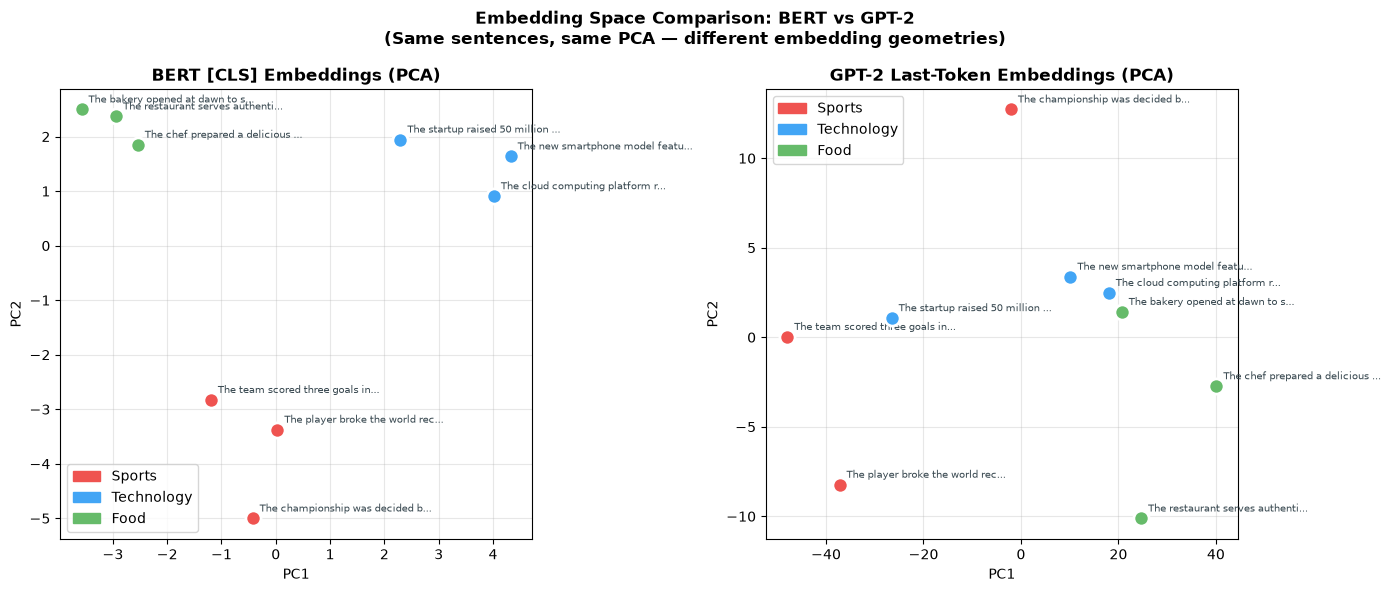

BERT [CLS] embeddings tend to cluster more strongly by topic.
GPT-2 last-token embeddings encode sequential prediction context.


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from transformers import (BertTokenizer, BertModel,
                          GPT2Tokenizer, GPT2Model)

# Load models
bert_tok   = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()

gpt2_tok   = GPT2Tokenizer.from_pretrained('./data/gpt2')
gpt2_tok.pad_token = gpt2_tok.eos_token
gpt2_model = GPT2Model.from_pretrained('./data/gpt2')
gpt2_model.eval()

# Sentence groups
sentences = [
    # Sports
    'The team scored three goals in the final match.',
    'The player broke the world record in the 100m sprint.',
    'The championship was decided by a penalty shootout.',
    # Technology
    'The startup raised 50 million dollars in Series B funding.',
    'The new smartphone model features a 200 megapixel camera.',
    'The cloud computing platform reduced infrastructure costs by 40 percent.',
    # Food
    'The restaurant serves authentic Italian pasta dishes.',
    'The chef prepared a delicious five course tasting menu.',
    'The bakery opened at dawn to sell freshly baked sourdough bread.',
]
group_labels = ['Sports']*3 + ['Technology']*3 + ['Food']*3
group_colors = {'Sports': '#EF5350', 'Technology': '#42A5F5', 'Food': '#66BB6A'}

def get_bert_embedding(text):
    inputs = bert_tok(text, return_tensors='pt', truncation=True, max_length=64)
    with torch.no_grad():
        out = bert_model(**inputs)
    return out.last_hidden_state[0, 0].numpy()  # [CLS]

def get_gpt2_embedding(text):
    inputs = gpt2_tok(text, return_tensors='pt', truncation=True, max_length=64)
    with torch.no_grad():
        out = gpt2_model(**inputs)
    return out.last_hidden_state[0, -1].numpy()  # last token

bert_embs = np.array([get_bert_embedding(s) for s in sentences])
gpt2_embs = np.array([get_gpt2_embedding(s) for s in sentences])

# PCA to 2D
pca = PCA(n_components=2, random_state=42)
bert_2d = pca.fit_transform(bert_embs)
gpt2_2d = pca.fit_transform(gpt2_embs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, embs_2d, title in [
    (axes[0], bert_2d, "BERT [CLS] Embeddings (PCA)"),
    (axes[1], gpt2_2d, "GPT-2 Last-Token Embeddings (PCA)"),
]:
    for i, (x, y) in enumerate(embs_2d):
        group = group_labels[i]
        color = group_colors[group]
        ax.scatter(x, y, c=color, s=120, edgecolors='white', lw=2, zorder=3)
        ax.annotate(sentences[i][:30]+'...', (x, y),
                    textcoords='offset points', xytext=(5, 5), fontsize=7,
                    color='#37474F')
    legend_handles = [mpatches.Patch(color=c, label=g)
                      for g, c in group_colors.items()]
    import matplotlib.patches as mpatches
    ax.legend(handles=legend_handles, fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.grid(alpha=0.3)

plt.suptitle('Embedding Space Comparison: BERT vs GPT-2\n(Same sentences, same PCA — different embedding geometries)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_embedding_space_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('BERT [CLS] embeddings tend to cluster more strongly by topic.')
print('GPT-2 last-token embeddings encode sequential prediction context.')

## 4. The Practical Decision Guide: When to Use Each

| Task | Use BERT | Use GPT | Why |
|---|---|---|---|
| Sentiment analysis | ✅ | ❌ | Needs full context for nuance; [CLS] works perfectly |
| Named entity recognition | ✅ | ❌ | Per-token classification with full bidirectional context |
| Question answering (extractive) | ✅ | ❌ | Span extraction benefits from bidirectional context |
| Text classification | ✅ | ❌ | [CLS] embedding excellent discriminator |
| Semantic similarity | ✅ | ❌ | Bidirectional embeddings cluster by meaning |
| Text generation / completion | ❌ | ✅ | Autoregressive design is ideal |
| Chatbots / dialogue | ❌ | ✅ | RLHF-tuned GPT excels at conversation |
| Code generation | ❌ | ✅ | Autoregressive token prediction suits code |
| Summarization | ⚠️ | ✅ | GPT generates; BERT can extract (extractive only) |
| Machine translation | ⚠️ | ✅ | Encoder-Decoder (T5/BART) is best; GPT does it via prompting |
| Sentence embeddings | ✅ | ⚠️ | BERT with pooling; specialized models like SBERT are better |

---

## 5. The Modern Convergence

An important trend: the strict BERT/GPT divide is blurring in modern models.

- **T5** (Google, 2020): frames all NLP as text-to-text, using an Encoder-Decoder architecture — combines BERT's understanding with GPT's generation.
- **GPT-4** (OpenAI, 2023): a decoder-only model that, at sufficient scale + RLHF, matches or exceeds BERT on many understanding benchmarks.
- **BART** (Facebook, 2020): denoising autoencoder combining bidirectional encoder + left-to-right decoder — excellent for summarization.
- **Unified LLMs** (Gemini, Claude, Llama 3): all decoder-only, but with so much scale that they generalize across all task types.

The practical implication: for most new applications in 2024+, a **large instruction-tuned decoder-only LLM** (like GPT-4 or LLaMA-3) can handle both understanding and generation tasks via prompting — making the BERT family more relevant for **resource-constrained** or **highly specialized** production settings where a fine-tuned BERT-size model (~110M params) is orders of magnitude cheaper to serve than a 70B LLM.

---

## 6. Summary

| | BERT | GPT |
|---|---|---|
| **Origin** | Encoder stack | Decoder stack |
| **Attention** | Bidirectional | Causal (unidirectional) |
| **Pre-training** | MLM + NSP | CLM |
| **Strengths** | Understanding, classification | Generation, completion |
| **2024 status** | Specialist (cheap, fast, focused) | General (large, expensive, flexible) |

### What's Next
Notebook 9 covers the **Hugging Face ecosystem** — the practical tools that make working with both model families fast and accessible.

---
*Phase 8, Notebook 8 of 10 — NLP From Scratch: Foundation to Advanced*